## Data Loading

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/Users/sakshamchauhan/Documents/Machine-Learning-/Machine Learning/Lecture-1/Project-1/insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA

In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

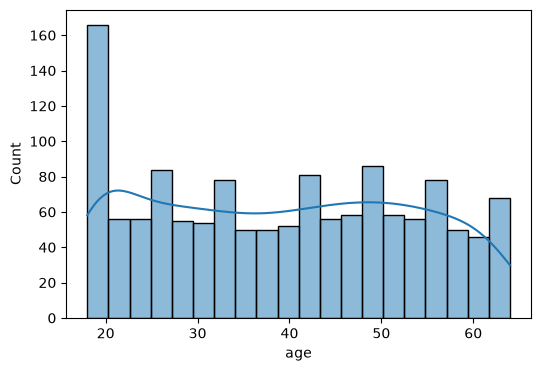

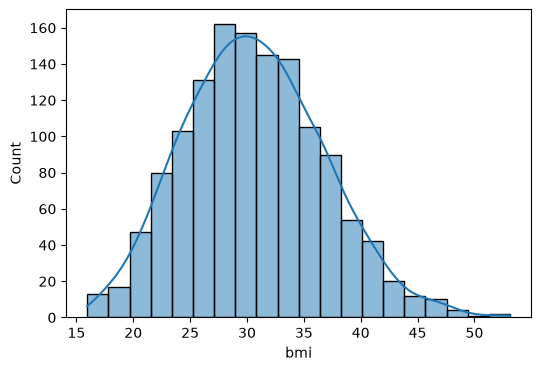

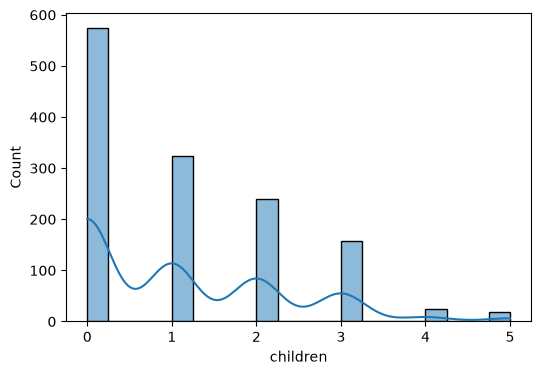

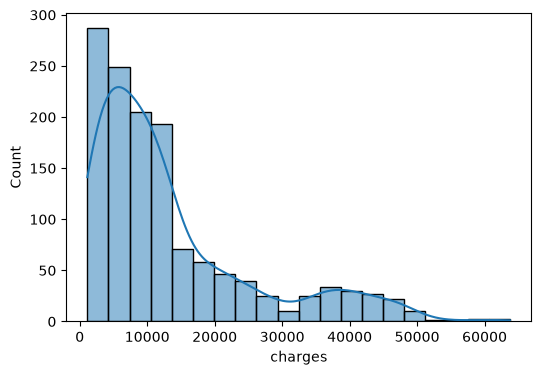

In [11]:
numeric_Col = ["age", "bmi", "children", "charges"]
for col in numeric_Col:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins =20)

<Axes: xlabel='children', ylabel='count'>

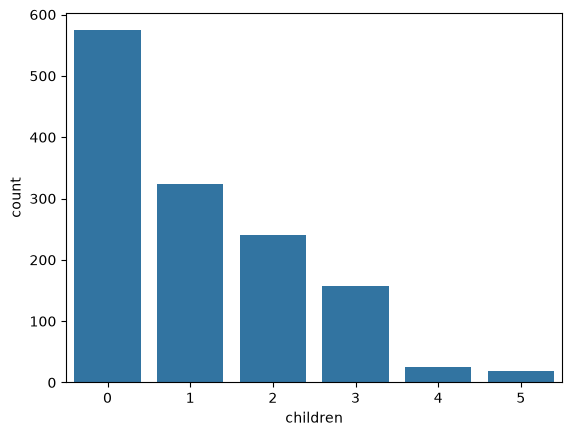

In [12]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

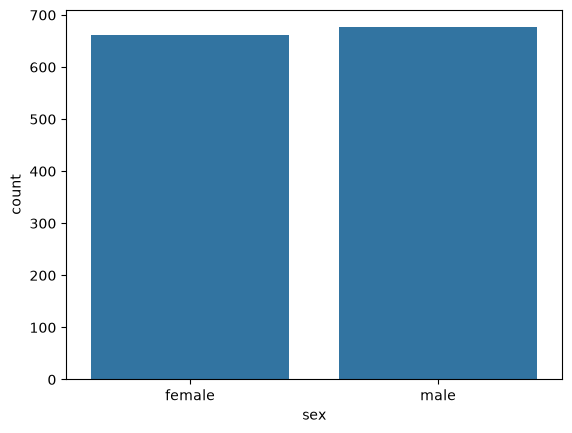

In [13]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

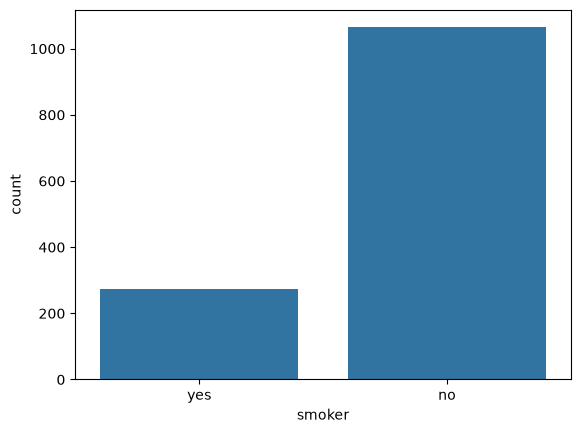

In [14]:
sns.countplot(x = df['smoker'])

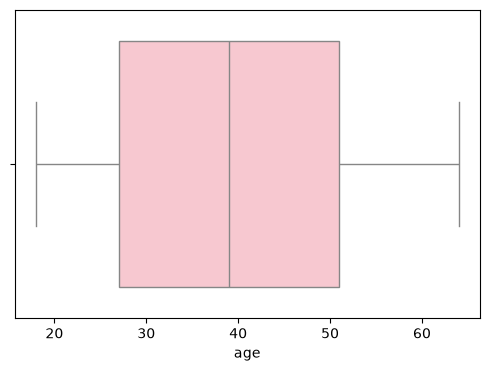

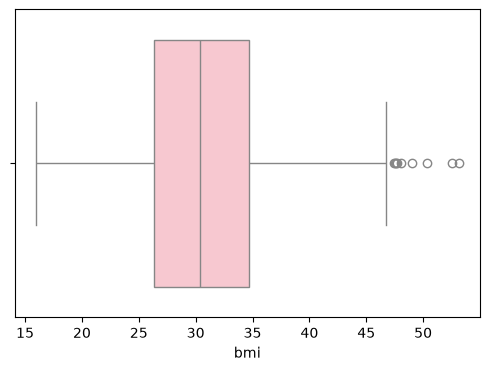

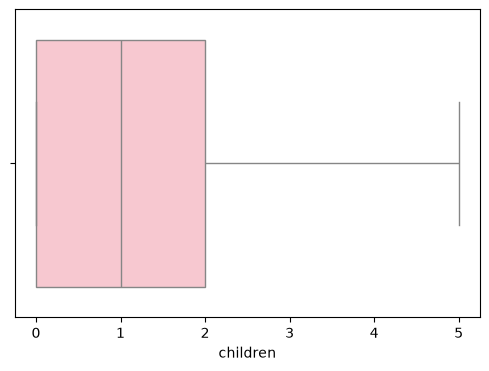

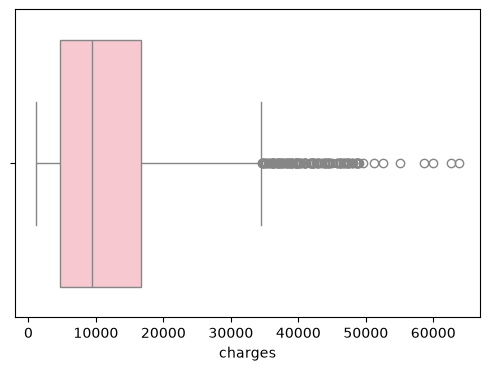

In [15]:
for col in numeric_Col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x= df[col], color='pink')

<Axes: >

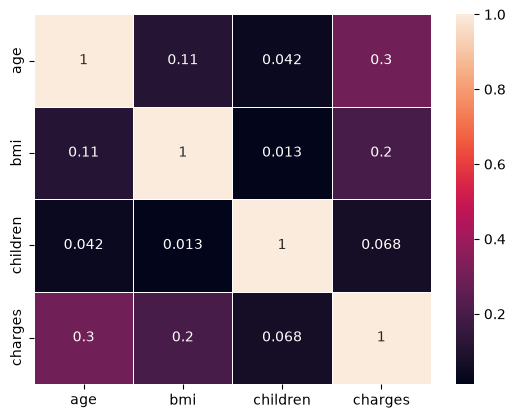

In [16]:
plt.Figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot = True, linewidths=0.5)

## Data Cleaning & Preprocessing

In [17]:
df_cleaned = df.copy()

In [18]:
df_cleaned.drop_duplicates(inplace = True)
df_cleaned.shape

(1337, 7)

In [19]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [20]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [24]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1 , 'no':0})

In [25]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [26]:
df_cleaned.rename(columns = {'sex': 'is_Female', 'smoker': 'is_smoker'}, inplace = True)

In [27]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [28]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [29]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'] , drop_first=True )

In [30]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [31]:
df_cleaned=df_cleaned.astype(int)

In [32]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


## Feature Engineering & Extraction

<Axes: xlabel='bmi', ylabel='Count'>

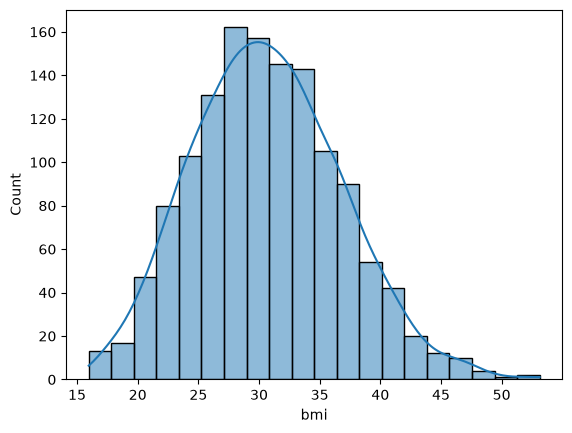

In [33]:
sns.histplot(df['bmi'], kde = True, bins =20)

In [34]:
df_cleaned['bmi_Category'] = pd.cut(
    df_cleaned['bmi'], bins = [0, 18.5 , 24.9, 29.9, 100], labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [35]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [36]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['bmi_Category'], drop_first = True)


In [37]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [38]:
df_cleaned.columns

Index(['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese'],
      dtype='str')

In [39]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [40]:
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [41]:
df_cleaned.columns

Index(['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese'],
      dtype='str')

In [42]:
from scipy.stats import pearsonr
selected_features = ['age', 'is_Female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese']

correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'pearsonr Correlation'])
correlation_df.sort_values(by='pearsonr Correlation', ascending=False)

,Feature,pearsonr Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_Category_Obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_Female,-0.058046
8,bmi_Category_Normal,-0.104042


In [43]:
categorical_features= [ 'is_Female', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese']
# Chi Square Test (Category vs Category)


In [44]:
from scipy.stats import chi2_contingency
alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
chi2_result = {}

for col in categorical_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision= "Reject Null Hypothesis" if p_val < alpha else "Accept Null Hypothesis"
    chi2_result[col] = {
        'chi2_statistics' : chi2_stat,
        'p_value' : p_val,
        'decision' : decision
    }

In [45]:
chi2_df = pd.DataFrame(chi2_result).T
chi2_df = chi2_df.sort_values(by='p_value', ascending=True)
chi2_df

,chi2_statistics,p_value,decision
is_smoker,848.219178,0.0,Reject Null Hypothesis
region_southeast,15.998167,0.001135,Reject Null Hypothesis
is_Female,10.258784,0.01649,Reject Null Hypothesis
bmi_Category_Obese,8.515711,0.036473,Reject Null Hypothesis
region_southwest,5.091893,0.165191,Accept Null Hypothesis
bmi_Category_Overweight,4.25149,0.235557,Accept Null Hypothesis
bmi_Category_Normal,3.708088,0.29476,Accept Null Hypothesis
region_northwest,1.13424,0.768815,Accept Null Hypothesis


In [46]:
final_df = df_cleaned[['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese', 'charges']]
final_df

,age,is_Female,bmi,children,is_smoker,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese,charges
0,-1.440418,1,-0.517949,-0.909234,1,0,1,0,16884
1,-1.511647,0,0.462463,-0.079442,0,0,0,1,1725
2,-0.799350,0,0.462463,1.580143,0,0,0,1,4449
3,-0.443201,0,-1.334960,-0.909234,0,1,0,0,21984
4,-0.514431,0,-0.354547,-0.909234,0,0,1,0,3866
...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,0,0,1,10600
1334,-1.511647,1,0.135659,-0.909234,0,0,0,1,2205
1335,-1.511647,1,0.952670,-0.909234,0,0,0,1,1629
1336,-1.297958,1,-0.844753,-0.909234,0,0,1,0,2007


## Linear Regression Model

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X = final_df.drop('charges', axis = 1)
y = final_df['charges']


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state = 42)

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3485.79, 63.95, 426.04,..., 554.29, 769.32,4138.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','is_Female','bmi',...,'bmi_Category_Normal', 'bmi_Category_Overweight','bmi_Category_Obese']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5940
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [54]:
y_pred = model.predict(X_test)

In [55]:
y_pred

array([ 7760.34132356,  5445.64489069, 14502.10361315, 32393.29644553,
        9070.71732806, 13470.35713461, 30069.31082071,  1259.63792506,
       11364.49343184, 10015.55256534, 10734.17792239, 32128.53608962,
       31490.31391762, 15919.45874611, 10127.83373522,  8481.55522481,
        5450.59875596, 32622.71276403,  3200.90069875,  4101.61840785,
        4973.71782258, 28766.30970063, 13882.38319697, 29511.1855851 ,
       31400.95594618,  6303.66877324, 35065.3200899 , 37832.04384446,
       12506.16769962, 14164.49316184,  7565.69839848, 13177.81960151,
         673.73551226, 11347.19769082, 37450.47314019, 13281.21362351,
        3712.40127109,  4520.38459957, 31674.48979286,  8252.96625291,
        5887.99474693, 30337.17772836, 35442.41548362, 13078.03406185,
        7952.22648879,  3034.03495085,  4964.44240121,  7577.70586868,
        3574.86444544, 10639.36001858,  8041.71250365, 10253.85603171,
       30359.45549156,  4909.76926137, 11593.08240374, 11741.58882556,
      

In [56]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [57]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.8028959848610377

In [59]:
n = X_test.shape[0]
p = X_test.shape[1]

In [60]:
adjusted_r2 = 1-((1-r2) * (n-1)/ (n-p-1))
adjusted_r2

0.7968078299532706